----

-----

=== Paso 4: Análisis exploratorio ===

In [1]:
# Análisis exploratorio

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from scipy import stats

In [2]:
# Importar archivos

path_01 = '/datasets/project_sql_result_01.csv'  # company_name, trips_amount (15–16 nov)
path_04 = '/datasets/project_sql_result_04.csv'  # dropoff_location_name, average_trips (nov)

df_companies = pd.read_csv(path_01)
df_dropoff  = pd.read_csv(path_04)



In [3]:
# Asegurar nombres limpios y tipos correctos

df_companies.columns = df_companies.columns.str.strip()
df_dropoff.columns = df_dropoff.columns.str.strip()


df_companies['trips_amount'] = pd.to_numeric(df_companies['trips_amount'], errors='coerce')
df_dropoff['average_trips']  = pd.to_numeric(df_dropoff['average_trips'],  errors='coerce')

print('\n=== INFO companies ===')
print(df_companies.info())
print('\n=== INFO dropoff ===')
print(df_dropoff.info())



=== INFO companies ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None

=== INFO dropoff ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
None


In [4]:
print('\n=== HEAD of companies ===')
display(df_companies.head())
print('\n=== HEAD of dropoff ===')
display(df_dropoff.head())


=== HEAD of companies ===


,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasing,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299



=== HEAD of dropoff ===


,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000


In [5]:
# Top 10 barrios por promedio de finalizaciones

top10 = (
    df_dropoff
    .sort_values('average_trips', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
print('\n=== Top 10 barrios por promedio de finalizaciones (nov 2017) ===')
display(top10)


=== Top 10 barrios por promedio de finalizaciones (nov 2017) ===


,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


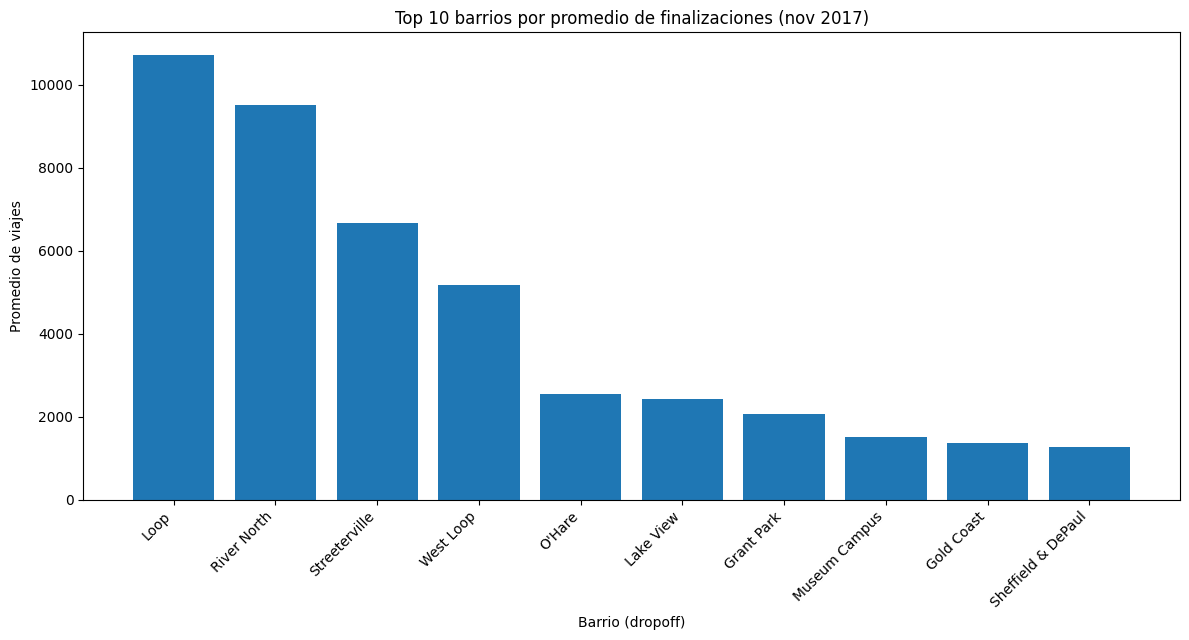

In [6]:
# Gráfico: Top 10 barrios por promedio de finalizaciones

plt.figure(figsize=(12, 6.5))
plt.bar(top10['dropoff_location_name'], top10['average_trips'])
plt.title('Top 10 barrios por promedio de finalizaciones (nov 2017)')
plt.xlabel('Barrio (dropoff)')
plt.ylabel('Promedio de viajes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

=== INTERPRETACIÓN ===

Alta concentración en el centro: Loop, River North y Streeterville lideran claramente, hay un salto notable respecto al resto.

West Loop queda en un segundo escalón; de ahí en adelante hay cola larga (demanda moderada y dispersa).

O’Hare aparece a mitad del Top 10.

Implicación operativa: priorizar cobertura y oferta (flota/incentivos) en Loop–River North–Streeterville–West Loop.

===========================================================================================

In [7]:
# Empresas vs. número de viajes

df_companies_sorted = (
    df_companies
    .sort_values('trips_amount', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
print('\n=== Top 10 empresas x número de viajes ===')
display(df_companies_sorted)


=== Top 10 empresas x número de viajes ===


,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasing,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299
5,Chicago Carriage Cab Corp,9181
6,City Service,8448
7,Sun Taxi,7701
8,Star North Management LLC,7455
9,Blue Ribbon Taxi Association Inc.,5953


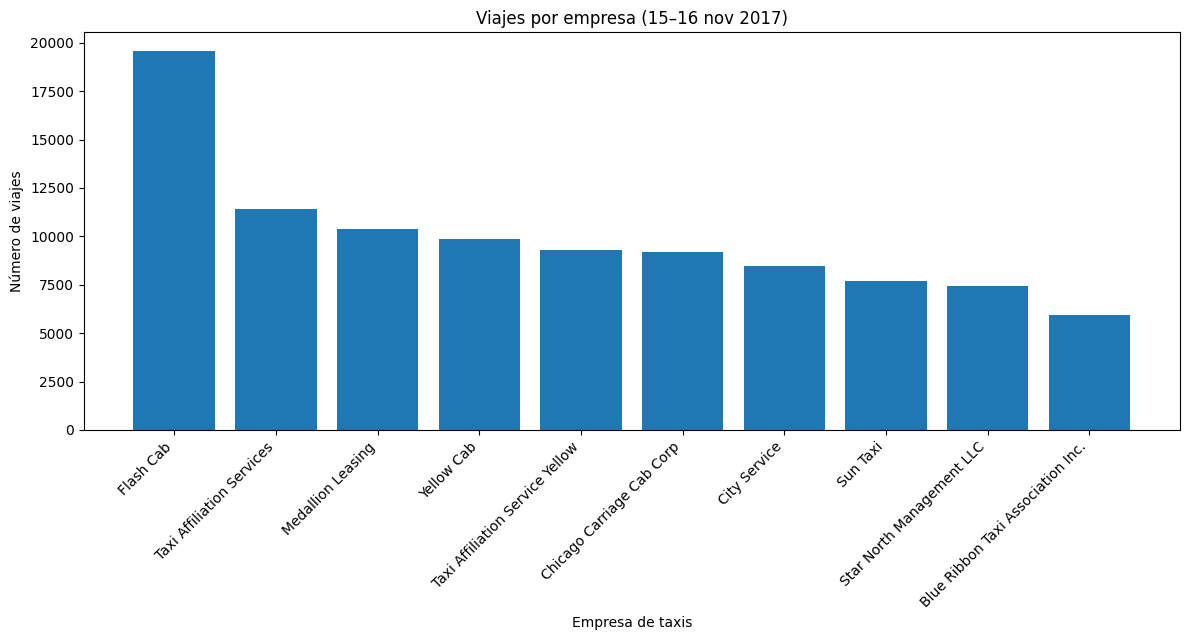

In [8]:
# Gráfico: Empresas vs. número de viajes

plt.figure(figsize=(12, 6.5))
plt.bar(df_companies_sorted['company_name'], df_companies_sorted['trips_amount'])
plt.title('Viajes por empresa (15–16 nov 2017)')
plt.xlabel('Empresa de taxis')
plt.ylabel('Número de viajes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

=== INTERPRETACIÓN ===

Flash Cab domina con clara ventaja.

El resto de las empresas registran ~50% del volumen de viajes de Flash Cab.

Del 3º al 10º (Medallion, Yellow Cab, etc.) las diferencias son menores, mercado fragmentado en el segmento medio.

La presencia de Yellow (dos marcas) es relevante pero lejos del líder.

Implicación: si buscas cobertura rápida, alíate con Flash Cab y Taxi Affiliation Services; para crecer después, compite en el bloque medio con precio/incentivos y foco geográfico. (Nota: es un snapshot de 2 días, úsalo como indicio, no como verdad anual.)

Plan de acción: volumen rápido = Flash Cab + Taxi Affiliation Services. Crecimiento sostenido = disputar el mid-tier con políticas de precio e incentivos.

===========================================================================================

=== PASO 5 ===

In [9]:
# Cargar y preparar

path_07 = '/datasets/project_sql_result_07.csv'
df = pd.read_csv(path_07)

In [10]:
# Info
print('\n=== INFO Weather ===')
df.info()

print('\n=== HEAD Weather ===')
df.head()


=== INFO Weather ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB

=== HEAD Weather ===


,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0


In [11]:
# Tipos correctos

df['start_ts'] = pd.to_datetime(df['start_ts'])

df['duration_seconds'] = pd.to_numeric(df['duration_seconds'], errors='coerce')

In [12]:
# Nos quedamos solo con Good/Bad y quitamos faltantes

df = df[df['weather_conditions'].isin(['Good', 'Bad'])].copy()
df = df.dropna(subset=['duration_seconds'])

print('=== REVISIÓN DE NO-NULL ===')
df.info()

=== REVISIÓN DE NO-NULL ===
<class 'pandas.core.frame.DataFrame'>
Int64Index: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   start_ts            1068 non-null   datetime64[ns]
 1   weather_conditions  1068 non-null   object        
 2   duration_seconds    1068 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 33.4+ KB


In [13]:
# Trabajar en minutos para interpretar mejor

df['duration_min'] = df['duration_seconds'] / 60

In [14]:
# Definir grupos

good = df.loc[df['weather_conditions'] == 'Good', 'duration_min']
bad  = df.loc[df['weather_conditions'] == 'Bad',  'duration_min']

print('Tamaños de muestra -> Good:', len(good), '| Bad:', len(bad))

print('\nMedias (min) -> Good:', good.mean().round(2), '| Bad:', bad.mean().round(2))

print('\nMedianas (min) -> Good:', good.median().round(2), '| Bad:', bad.median().round(2))

Tamaños de muestra -> Good: 888 | Bad: 180

Medias (min) -> Good: 33.33 | Bad: 40.45

Medianas (min) -> Good: 30.0 | Bad: 42.33


In [15]:
# Hipótesis y nivel de significación (dos colas)

alpha = 0.05

u_stat, p_value = stats.mannwhitneyu(bad, good, alternative='two-sided')
print('\nMann–Whitney U (two-sided) -> U = {:.0f}, p-value = {:.4f}'.format(u_stat, p_value))

if p_value < alpha:
    print('Decisión: Rechazamos H0 (p < α). Hay evidencia de diferencia en la duración.')
else:
    print('Decisión: No rechazamos H0 (p ≥ α). No hay evidencia suficiente de diferencia.')



Mann–Whitney U (two-sided) -> U = 108194, p-value = 0.0000
Decisión: Rechazamos H0 (p < α). Hay evidencia de diferencia en la duración.


=== RESULTADOS DE HIPÓTESIS ===

->  "La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos"


Eso implica comparar dos grupos independientes:

-> Bad (lluvia/tormenta)

-> Good (lo demás)

y ver si su tendencia central (duración) es distinta. Como la consigna dice “cambia”, la prueba es de dos colas (no asumimos que aumente o disminuya).

Hipótesis y nivel de significación (dos colas)

H0: la duración promedio es igual en sábados "Good" y "Bad"

H1: la duración promedio es distinta entre "Good" y "Bad"

-> Elegimos α = 0.05 y un test no paramétrico (Mann–Whitney U)

Las duraciones suelen ser asimétricas y con outliers.

-> MWU no asume normalidad y compara distribuciones/medianas

Se utilizó Mann–Whitney U (MWU) porque no requiere normalidad y compara la posición de las distribuciones (≈ medianas).
 
(El t-test funciona bien con datos “bonitos” (normales). Welch es más flexible con la dispersión, pero ambos pueden fallar si la forma de la distribución es rara o hay extremos.)


===CONCLUSIÓN ===

Rechazamos H0 (p < 0.05). Con clima Bad los viajes duran más que con clima Good en el trayecto Loop -> O’Hare.

===========================================================================================



In [16]:
print(f'Tamaños -> Good: {len(good)} | Bad: {len(bad)}')
print(f'Medias (min) -> Good: {good.mean():.2f} | Bad: {bad.mean():.2f}')
print(f'Desv. (min) -> Good: {good.std(ddof=1):.2f} | Bad: {bad.std(ddof=1):.2f}')

# Prueba t de Welch (dos colas)

alpha = 0.05
t_stat, p_val = stats.ttest_ind(bad, good, equal_var=False)

print(f'\nWelch t-test: t = {t_stat:.3f}, p = {p_val:.4f}')

if p_val < alpha:
    print('Decisión: Rechazamos H0 (p < 0.05). Evidencia de diferencia en la media.')
else:
    print('Decisión: No rechazamos H0 (p ≥ 0.05). No hay evidencia suficiente de diferencia.')

Tamaños -> Good: 888 | Bad: 180
Medias (min) -> Good: 33.33 | Bad: 40.45
Desv. (min) -> Good: 12.65 | Bad: 12.02

Welch t-test: t = 7.186, p = 0.0000
Decisión: Rechazamos H0 (p < 0.05). Evidencia de diferencia en la media.


=== CONCLUSIÓN ===

=== Welch t-test ===

-> Rechazamos H0 (t=7.19, p<0.001). La duración promedio sí cambia entre sábados Bad y Good en el trayecto Loop -> O’Hare: con clima Bad es mayor (≈40.45 min vs 33.33 min), una diferencia de ~ +7.1 min (~21% más).

===========================================================================================

=== HALLAZGOS GENERALES ===

Demanda concentrada en el centro: Loop, River North y Streeterville lideran en finalizaciones, West Loop sigue. O’Hare aparece a mitad del top.

Estructura competitiva: Flash Cab y Taxi Affiliation Services concentran la mayor parte de los viajes (15–16 nov); el resto presenta diferencias porcentuales menores entre sí.

Clima importa (sábados): la duración Loop -> O’Hare aumenta con lluvia/tormenta.

MWU / Welch: p < 0.05 -> rechazamos H0

Magnitud: media ~ 40.5 min (Bad) vs 33.3 min (Good) (~+7.1 min, ≈+21%); mediana ~42.3 vs 30.0 min.




===========================================================================================